# Dataset sul Traffico di Rete

Il dataset che useremo in questa esercitazione contiene caratteristiche estratte da sessioni di traffico di rete, progettate per l'analisi e il rilevamento di malware basato sul comportamento della rete. Le caratteristiche sono organizzate in diverse categorie funzionali.

## Categorie principali di caratteristiche

### Informazioni sulla sessione
- **Informazioni temporali**: `start`, `duration`, `cap_date`, `daysTime`, `weekDay`
- **Informazioni di connessione**: Indirizzi IP e porte (`...ip`, `...port`)
- **Etichette**: `label`, `labelSS` (classificazione del malware)

### Metriche TCP/IP
- **Statistiche pacchetti**: Conteggio pacchetti (`packets_...`), dimensioni (`packetsize...`), rapporti (`packetsAB_ratio`)
- **Flag TCP**: Pacchetti ACK (`ack_...`), PUSH (`push_...`), RESET (`reset_...`), URG (`urg_...`)
- **Tempi di arrivo**: Tempi tra pacchetti (`packetinterarrivel_...`)
- **Time-to-live**: Valori TTL per pacchetti client/server (`ttl_...`, `ttlA...`, `ttlB...`)
- **Analisi TCP**: Pacchetti persi, ritrasmessi (`tcpanalysis...`)
- **Bytes trasferiti**: Totali e rapporti (`bytes_...`, `bytesAB_ratio`)

### Protocollo HTTP
- **Richieste HTTP**: Metodi GET/POST (`http_GET`, `http_POST`), conteggi (`httpcount...`)
- **Bytes HTTP**: Dimensioni richieste/risposte (`httpreqbytes_...`, `httprespbytes_...`)
- **Tempi HTTP**: Tempi di risposta (`httptime...`), tempi tra richiesta e risposta (`httpinterarrivel_...`)
- **Cookie**: Conteggio e valori (`httpcookiecount`, `httpcookievalues_...`)
- **Host dominante**: URL, rank Alexa, tipo di browser (`httpdom...`)
- **Classificazione URL**: Identificatori per CDN, ad, cloud, ecc. (`iscdnhttp`, `isadhttp`, `iscloudhttp`, etc.)

### Protocollo DNS
- **Risposta DNS**: Conteggio indirizzi, risposte, flag (`dnscountaddresses`, `dns_flag`)
- **Hostname DNS**: Nome host, TTL (`dnshostname`, `dnsminttl`)
- **Tempi DNS**: Tempo di risposta (`dns_time`)
- **Rank Alexa**: Rank del server nella risposta DNS (`dns_alexaRank`)

### Protocollo SSL/TLS
- **Handshake SSL**: Durata (`sslhandshakeduration_...`)
- **Bytes SSL**: Bytes richiesta/risposta (`sslreqbytes_...`, `sslrespbytes_...`)
- **Certificati**: Conteggio, rapporti (`sslcountcertificates`, `sslratio...`)
- **Cifrari e algoritmi**: Conteggio cifrari supportati (`sslcountclient_...`, `sslcountserver_...`)
- **Versioni SSL**: Numero di versioni, versione dominante (`ssldomserver_ciphersuite`, `ssldomserver_compression`)

### Informazioni geografiche e di routing
- **ASN**: Numero di sistemi autonomi (`asn_...`)
- **Paesi**: Numero di paesi per client/server (`country_...`)


# Obiettivo
  Partendo dalle varie features che corrispondono a come un dispositivo interagisce nella rete, bisogna classificare la tipologia di dispositivo (`device_category`)

In [94]:
import pandas as pd
df = pd.read_csv('../datasets/iot_device_test.csv')

### Stampiamo le colonne

In [95]:
df.columns

Index(['ack', 'ack_A', 'ack_B', 'bytes', 'bytes_A', 'bytes_A_B_ratio',
       'bytes_B', 'ds_field_A', 'ds_field_B', 'duration',
       ...
       'suffix_is_co.il', 'suffix_is_com', 'suffix_is_com.sg',
       'suffix_is_else', 'suffix_is_empty_char_value',
       'suffix_is_googleapis.com', 'suffix_is_net', 'suffix_is_org',
       'suffix_is_unresolved', 'device_category'],
      dtype='str', length=298)

In [96]:
# Verifica dei valori NaN
nan_counts = df.isna().sum()
print(f"Colonne con valori NaN:")
print(nan_counts[nan_counts > 0])

Colonne con valori NaN:
Series([], dtype: int64)


### Vediamo che tipologia di valori dobbiamo classificare

In [97]:
df["device_category"]

0      baby_monitor
1      baby_monitor
2      baby_monitor
3      baby_monitor
4      baby_monitor
           ...     
895           watch
896           watch
897           watch
898           watch
899           watch
Name: device_category, Length: 900, dtype: str

In [98]:
#Vediamo quali sono i device che abbiamo
df["device_category"].unique()

<StringArray>
[   'baby_monitor',          'lights',   'motion_sensor', 'security_camera',
  'smoke_detector',          'socket',      'thermostat',              'TV',
           'watch']
Length: 9, dtype: str

In [99]:
#Vediamo come sono distribuiti i device
df["device_category"].value_counts()
#Abbiamo quindi un dataset bilanciato.

device_category
baby_monitor       100
lights             100
motion_sensor      100
security_camera    100
smoke_detector     100
socket             100
thermostat         100
TV                 100
watch              100
Name: count, dtype: int64

In [100]:
#Per ogni categoria dobbiamo assegnare un id che funziona da label per la classificazione
devices = df["device_category"].unique()


In [101]:
device_id_mapping = {i: device for i, device in enumerate(devices)}
print(device_id_mapping)

{0: 'baby_monitor', 1: 'lights', 2: 'motion_sensor', 3: 'security_camera', 4: 'smoke_detector', 5: 'socket', 6: 'thermostat', 7: 'TV', 8: 'watch'}


In [102]:
df['device_category'] = df['device_category'].map({device: i for i, device in enumerate(devices)})


In [103]:
df['device_category']

0      0
1      0
2      0
3      0
4      0
      ..
895    8
896    8
897    8
898    8
899    8
Name: device_category, Length: 900, dtype: int64

# Troppe feature, dobbiamo filtrare

### Metodo per filtrare: utilizzare la varianza

- rimuoviamo colonne costanti (varianza 0) o  quasi (varianza molto bassa) che danno poca informazione

Nessuna relazione con la feature target

Stiamo pulendo il dataset, non stiamo ancora facendo nessuna considerazione di utilità

## ATTENZIONE: Se le feature sono su scale diverse, alcune possono avere varianza alta solo perché hanno valori grandi, non perché sono più informative. Utilizzare questo metodo solo per ridurre feature quasi costanti

suffix_is_org                        0.0
suffix_is_net                        0.0
suffix_is_googleapis.com             0.0
http_cookie_values_entropy           0.0
http_cookie_values_var               0.0
http_cookie_values_stdev             0.0
subdomain_is_whp.hou9.cold.extweb    0.0
subdomain_is_www                     0.0
subdomain_is_feeds                   0.0
subdomain_is_h10141.www1             0.0
subdomain_is_img                     0.0
subdomain_is_whp.aus1.cold.extweb    0.0
B_port_is_9543                       0.0
subdomain_is_99sets                  0.0
subdomain_is_ccc                     0.0
B_port_is_8280                       0.0
is_img_http                          0.0
is_ad_http                           0.0
B_port_is_54975                      0.0
B_port_is_5223                       0.0
http_req_bytes_stdev                 0.0
http_req_bytes_var                   0.0
http_req_bytes_entropy               0.0
B_port_is_5222                       0.0
http_has_locatio

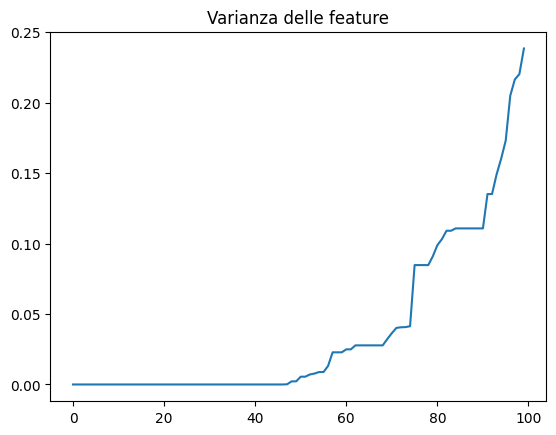

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.feature_selection import VarianceThreshold

X = df.drop(columns=['device_category'])
y = df['device_category']

# calcolo i valori di varianza e li ordiniamo dal più piccolo al più grande
variances = X.var().sort_values()
print(variances.head(30))   # le più basse

print(variances.tail(5))   # le più alte

plt.plot(variances.values[:100])
plt.title("Varianza delle feature")
plt.show()

In [105]:
threshold = 0.1
selected_features = variances[variances > threshold].index
X_var = X[selected_features]

X_var

,subdomain_is_else,B_port_is_80,domain_is_else,http_count_req_content_type,is_http,http_count_user_agents,http_count_host,http_has_user_agent,http_has_resp_content_type,http_has_req_content_type,...,http_dom_host_alexaRank,http_time_min,http_time_firstQ,http_time_avg,http_time_median,http_time_thirdQ,http_time_max,ssl_dom_server_name_alexaRank,http_time_sum,http_time_var
0,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
1,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
2,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
3,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
4,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0
896,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0
897,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0
898,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0


### Possiamo ora filtrare le colonne in base al modulo della correlazione

ssl_count_client_mac_algs          0.544407
reset_A                            0.493785
ssl_req_bytes_min                  0.399735
ttl_B_min                          0.380410
ttl_thirdQ                         0.370152
reset_B                            0.358092
ttl_B_stdev                        0.334591
ttl_max                            0.333855
packet_size_A_thirdQ               0.325068
ssl_dom_version                    0.320143
ssl_ratio_server_name              0.319185
ssl_count_transactions             0.319185
ssl_count_server_compression       0.319185
ssl_count_server_elliptic_curve    0.319185
ssl_count_version                  0.319185
ssl_count_client_compressions      0.319185
ssl_count_server_name              0.319185
ssl_count_server_ciphersuite       0.319185
is_ssl                             0.319185
packet_size_A_entropy              0.318804
dtype: float64


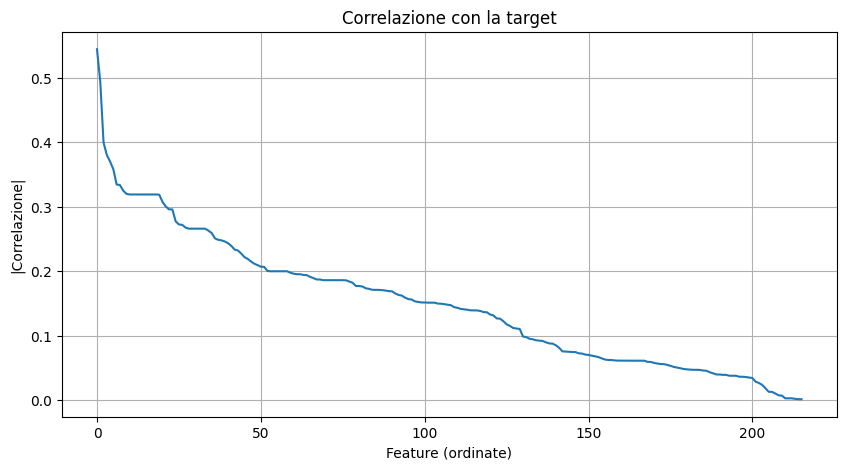

In [106]:
# Calcolo della correlazione tra ogni feature e la target
corr_with_target = X_var.corrwith(y)

# Prendo il valore assoluto (non mi interessa il segno)
corr_with_target = corr_with_target.abs()

# Ordino le feature dalla più correlata alla meno correlata
corr_with_target = corr_with_target.sort_values(ascending=False)

# Stampo le più importanti
print(corr_with_target.head(20))

plt.figure(figsize=(10,5))
plt.plot(corr_with_target.values)
plt.title("Correlazione con la target")
plt.xlabel("Feature (ordinate)")
plt.ylabel("|Correlazione|")
plt.grid(True)
plt.show()

In [107]:
# Seleziono le top-k feature più correlate
top_k = 50

selected_features = corr_with_target.head(top_k).index

# Dataset finale
cleaned_df = X_var[selected_features]
# Aggiungo la variabile target
cleaned_df["device_category"] = y

# Stampo le dimensioni del nuovo dataframe
print(f"Dimensioni del nuovo DataFrame: {cleaned_df.shape}")

# Stampo il numero di feature selezionate (senza la target)
print(f"Features selezionate: {len(selected_features)}")

Dimensioni del nuovo DataFrame: (900, 51)
Features selezionate: 50


In [108]:
cleaned_df.head()

,ssl_count_client_mac_algs,reset_A,ssl_req_bytes_min,ttl_B_min,ttl_thirdQ,reset_B,ttl_B_stdev,ttl_max,packet_size_A_thirdQ,ssl_dom_version,...,B_port_is_else,bytes_A_B_ratio,ssl_dom_server_ciphersuite,packet_size_B_avg,ssl_req_bytes_firstQ,ttl_B_var,packet_inter_arrivel_B_max,reset,ds_field_B,device_category
0,1,2,32,33,225.0,0,45.201365,225,85.5,769,...,1,1.135096,49171,378.444444,32.0,2043.163399,0.507894,2,0,0
1,1,2,32,33,226.0,0,45.437057,226,85.5,769,...,1,1.135096,49171,378.444444,32.0,2064.526144,0.527756,2,0,0
2,1,2,32,35,228.0,0,45.463948,228,85.5,769,...,1,1.124640,49171,378.444444,32.0,2066.970588,0.523921,2,0,0
3,1,2,32,34,228.0,0,45.699645,228,85.5,769,...,1,1.124640,49171,378.444444,32.0,2088.457516,0.696363,2,0,0
4,1,2,32,34,227.0,0,42.095300,227,85.5,769,...,1,1.163949,49171,324.380952,32.0,1772.014286,0.555956,2,0,0


## Limiti della correlazione con target multiclasse

In questa fase abbiamo selezionato le feature utilizzando la **correlazione** con la variabile target.  
Tuttavia, è importante evidenziare un limite concettuale di questo approccio.

La correlazione (in particolare quella di Pearson) è definita per **variabili numeriche continue**.  
Nel nostro caso, il target (`device_category`) è una variabile **categorica multiclasse**, che è stata convertita in numeri tramite encoding (ad esempio: 0: 'baby_monitor', 1: 'lights', 2: 'motion_sensor').

Questo introduce un problema:

> la correlazione assume implicitamente un **ordine e una distanza** tra le classi che in realtà non esistono.

Ad esempio, l'encoding suggerisce che:

baby monitor < lights < motion sensor

ma questa relazione **non ha alcun significato reale**.

Di conseguenza:
- i valori di correlazione possono essere **fuorvianti**
- il risultato dipende dall’encoding scelto
- alcune relazioni tra feature e target potrebbero non essere catturate correttamente

---

## Un’alternativa: Mutual Information

Per superare questo limite, possiamo utilizzare la **Mutual Information (MI)**.

La Mutual Information misura la **dipendenza statistica** tra una feature e il target, senza assumere:
- linearità
- ordine tra le classi

In particolare:
- funziona correttamente con target **multiclasse**
- cattura anche relazioni **non lineari**
- è più robusta rispetto all’encoding delle classi

Nel prossimo passo utilizzeremo quindi la Mutual Information per selezionare le feature e confronteremo i risultati con quelli ottenuti tramite correlazione.

In [109]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Target
y = df['device_category']  # usa la colonna già encodata

# Feature dopo variance threshold
X = X_var.copy()

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_series = pd.Series(mi_scores, index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

top50_mi = mi_series.head(50).index.tolist()
top50_corr = [col for col in cleaned_df.columns if col != 'device_category']

# Feature in comune
common_features = set(top50_corr).intersection(set(top50_mi))

# Solo correlazione
only_corr = set(top50_corr) - set(top50_mi)

# Solo mutual information
only_mi = set(top50_mi) - set(top50_corr)

print(f"Feature comuni: {len(common_features)}")
print(f"Solo correlazione: {len(only_corr)}")
print(f"Solo mutual information: {len(only_mi)}")

Feature comuni: 10
Solo correlazione: 40
Solo mutual information: 40


**La bassa sovrapposizione tra i due insiemi di feature evidenzia i limiti della selezione basata sulla correlazione in contesti multiclasse.**  
Mentre la correlazione cattura solo relazioni lineari ed è sensibile all’encoding arbitrario del target, 

la Mutual Information è in grado di identificare dipendenze più generali, incluse quelle non lineari.  

Questo spiega la significativa differenza nelle feature selezionate.

In [110]:
from sklearn.model_selection import train_test_split

#utilizzando il df pulito dalla correlazione
# X = cleaned_df.drop(columns=['device_category'])
# y = cleaned_df['device_category']

#utilizzando il df pulito dalla mutual information
X = X_var[top50_mi]
y = df['device_category']

# Utilizza train_test_split con stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Visualizza le dimensioni dei set di addestramento e test
print(f"Dimensioni del set di addestramento: {X_train.shape}")
print(f"Dimensioni del set di test: {X_test.shape}")

Dimensioni del set di addestramento: (720, 50)
Dimensioni del set di test: (180, 50)


### Normalizziamo

In [111]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Accuracy (sklearn-multinomial): 0.8500
Precision (sklearn-multinomial): 0.8907
Recall (sklearn-multinomial): 0.8500
F1 Score (sklearn-multinomial): 0.8326


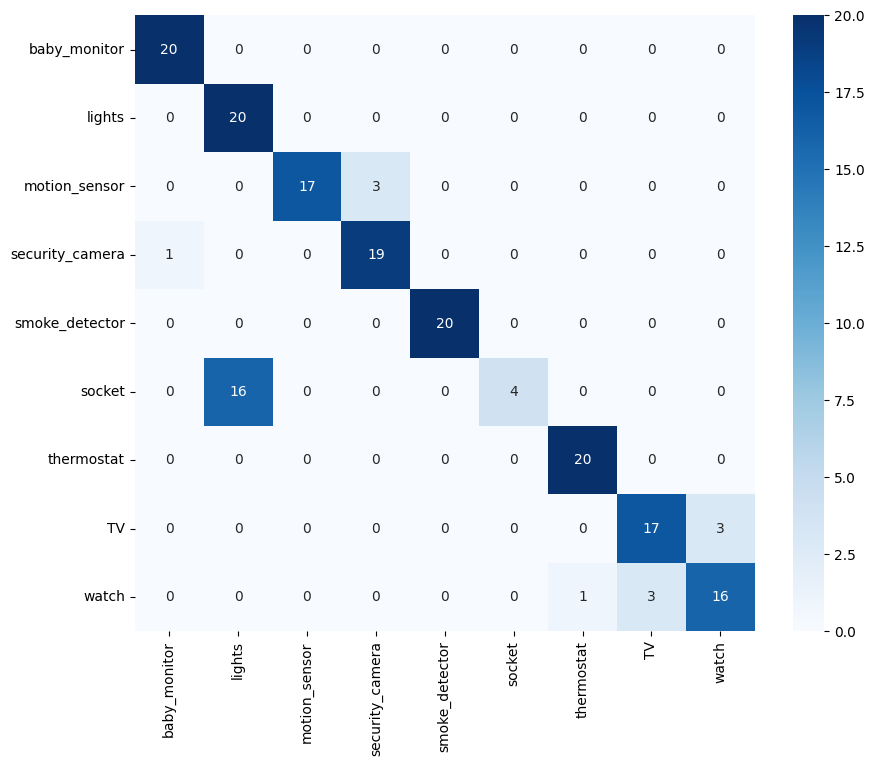

In [112]:
## Usiamo sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
logistic_model_sklearn = LogisticRegression(solver='lbfgs', max_iter=10000)
logistic_model_sklearn.fit(X_train, y_train)

#metriche calcolate sul test
accuracy_sklearn_multi = accuracy_score(y_test, y_pred_multi)
precision_sklearn_multi = precision_score(y_test, y_pred_multi, average='weighted')
recall_sklearn_multi = recall_score(y_test, y_pred_multi, average='weighted')
f1_sklearn_multi = f1_score(y_test, y_pred_multi, average='weighted')

print(f"Accuracy (sklearn-multinomial): {accuracy_sklearn_multi:.4f}")
print(f"Precision (sklearn-multinomial): {precision_sklearn_multi:.4f}")
print(f"Recall (sklearn-multinomial): {recall_sklearn_multi:.4f}")
print(f"F1 Score (sklearn-multinomial): {f1_sklearn_multi:.4f}")
# Calcolo della matrice di confusione
cm_sklearn = confusion_matrix(y_test, y_pred_multi)
# Visualizzazione della matrice di confusione
plt.figure(figsize=(10, 8))
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=devices, 
            yticklabels=devices)
plt.show()

### SKLEARN OVA

Accuracy OVA: 0.8278
Precision OVA: 0.8763
Recall OVA: 0.8278
F1 Score OVA: 0.8114


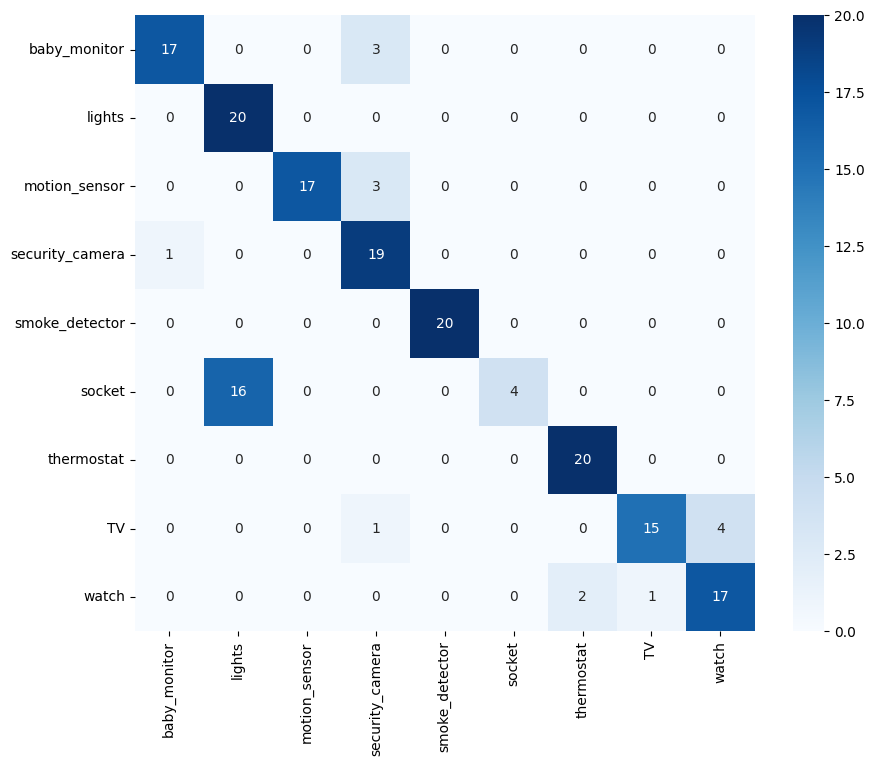

In [113]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Inizializza il modello OVA
lr_ova = OneVsRestClassifier(LogisticRegression(solver='liblinear', max_iter=10000))

# Addestra il modello
lr_ova.fit(X_train, y_train)

# Fai predizioni
y_pred_ova = lr_ova.predict(X_test)

# Metriche
accuracy_sklearn_ova = accuracy_score(y_test, y_pred_ova)
precision_sklearn_ova = precision_score(y_test, y_pred_ova, average='weighted')
recall_sklearn_ova = recall_score(y_test, y_pred_ova, average='weighted')
f1_sklearn_ova = f1_score(y_test, y_pred_ova, average='weighted')
# Stampa i risultati
print(f"Accuracy OVA: {accuracy_sklearn_ova:.4f}")
print(f"Precision OVA: {precision_sklearn_ova:.4f}")
print(f"Recall OVA: {recall_sklearn_ova:.4f}")
print(f"F1 Score OVA: {f1_sklearn_ova:.4f}")
# Calcolo della matrice di confusione
ova_sklearn = confusion_matrix(y_test, y_pred_ova)
# Visualizzazione della matrice di confusione
plt.figure(figsize=(10, 8))
sns.heatmap(ova_sklearn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=devices, 
            yticklabels=devices)
plt.show()



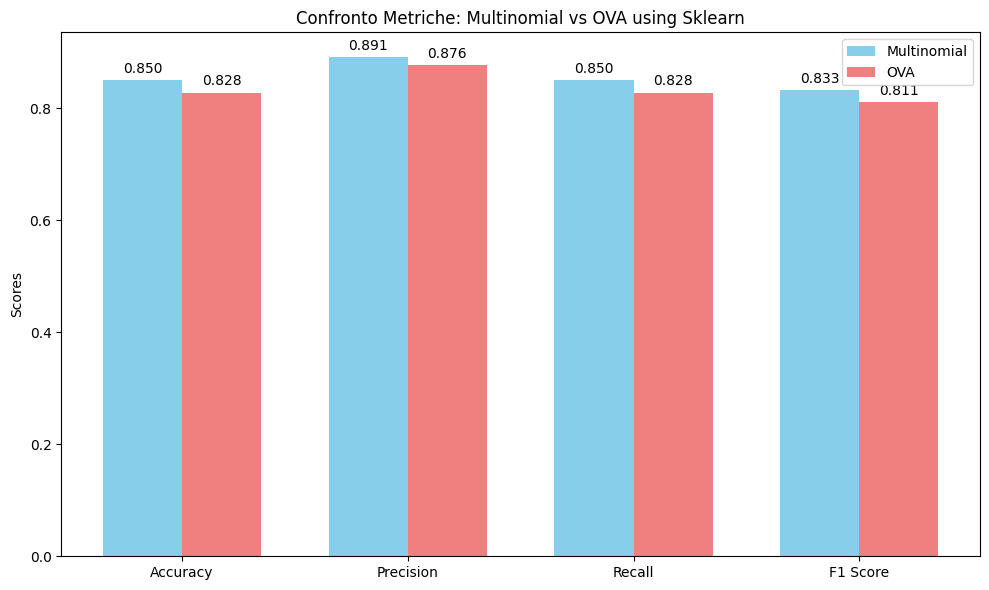

In [114]:
import numpy as np

import matplotlib.pyplot as plt

# Dati per il grafico
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
sklearn_multi_values = [
    accuracy_sklearn_multi,
    precision_sklearn_multi,
    recall_sklearn_multi,
    f1_sklearn_multi
]
sklearn_ova_values = [
    accuracy_sklearn_ova,
    precision_sklearn_ova,
    recall_sklearn_ova,
    f1_sklearn_ova
]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, sklearn_values, width, label='Multinomial', color='skyblue')
rects2 = ax.bar(x + width/2, ova_values, width, label='OVA', color='lightcoral')

# Aggiungi testo sopra ogni barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

# Aggiungi etichette, titolo e legenda
ax.set_ylabel('Scores')
ax.set_title('Confronto Metriche: Multinomial vs OVA using Sklearn')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()
plt.show()

# SOLUZIONE OVA - Implementando da zero l'algoritmo

In [115]:
class LogisticRegressionOVA:
    """
    Implementazione One-vs-All (OVA) per la regressione logistica multiclasse
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        Inizializzazione del modello
        
        Parametri:
        learning_rate: tasso di apprendimento per la discesa del gradiente
        n_iterations: numero di iterazioni per la discesa del gradiente
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.classifiers = []  # Lista di classificatori binari
        self.classes = None    # Classi uniche
    
    def fit(self, X, y):
        """
        Addestra un classificatore binario per ogni classe usando l'approccio OVA
        
        Parametri:
        X -- matrice delle feature di shape (m, n)
        y -- vettore delle etichette di shape (m,)
        """
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        
        print(f"Addestramento di {n_classes} classificatori OVA...")
        
        # Aggiungiamo una colonna di 1 per il termine di bias
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        
        # Addestriamo un classificatore per ogni classe
        for i, c in enumerate(self.classes):
            print(f"\nClassificatore per classe {c} vs resto:")
            
            # Creiamo etichette binarie: 1 per la classe corrente, 0 per tutte le altre
            y_binary = np.where(y == c, 1, 0)
            
            # Creiamo e addestriamo il classificatore
            classifier = self._train_binary_classifier(X_bias, y_binary)
            self.classifiers.append(classifier)
            
            # Calcoliamo l'accuratezza sul training set
            y_pred = self._predict_binary(X_bias, classifier) >= 0.5
            accuracy = np.mean(y_pred == y_binary)
            print(f"Accuratezza per classe {c}: {accuracy:.4f}")
        
        print("\nAddestramento OVA completato!")
    
    def _train_binary_classifier(self, X, y):
        """
        Addestra un singolo classificatore binario
        
        Parametri:
        X -- matrice delle feature con bias di shape (m, n+1)
        y -- vettore delle etichette binarie di shape (m,)
        
        Restituisce:
        weights -- pesi ottimizzati del classificatore
        """
        m, n = X.shape
        weights = np.zeros(n)
        
        for i in range(self.n_iterations):
            # Calcolo della previsione
            z = np.dot(X, weights)
            h = self._sigmoid(z)
            
            # Calcolo del gradiente
            gradient = 1/m * np.dot(X.T, (h - y))
            
            # Aggiornamento dei pesi
            weights = weights - self.learning_rate * gradient
            
            # Stampa periodica del costo
            if (i % 200 == 0) or (i == self.n_iterations - 1):
                cost = self._compute_cost(X, y, weights)
                print(f"  Iterazione {i}: Costo = {cost:.6f}")
        
        return weights
    
    def _sigmoid(self, z):
        """
        Funzione sigmoide: trasforma un numero reale in una probabilità (0-1)
        """
        # Limitiamo z per evitare overflow/underflow numerici
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def _compute_cost(self, X, y, weights):
        """
        Calcola la funzione di costo (log loss)
        
        J(w) = -1/m * sum(y*log(h) + (1-y)*log(1-h))
        """
        m = X.shape[0]
        h = self._predict_binary(X, weights)
        
        # Per evitare log(0)
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)
        
        cost = -1/m * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
        return cost
    
    def _predict_binary(self, X, weights):
        """
        Calcola la probabilità per un classificatore binario
        """
        z = np.dot(X, weights)
        return self._sigmoid(z)
    
    def predict_proba(self, X):
        """
        Calcola le probabilità per tutte le classi
        
        Parametri:
        X -- matrice delle feature di shape (m, n)
        
        Restituisce:
        probs -- matrice di probabilità di shape (m, n_classes)
        """
        # Aggiungiamo una colonna di 1 per il termine di bias
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        probs = np.zeros((n_samples, n_classes))
        
        # Calcoliamo le probabilità per ogni classe
        for i, classifier in enumerate(self.classifiers):
            probs[:, i] = self._predict_binary(X_bias, classifier)
        
        # Normalizziamo le probabilità per avere somma 1
        probs = probs / np.sum(probs, axis=1, keepdims=True)
        
        return probs
    
    def predict(self, X):
        """
        Predice la classe con la probabilità più alta
        
        Parametri:
        X -- matrice delle feature di shape (m, n)
        
        Restituisce:
        y_pred -- vettore delle classi predette di shape (m,)
        """
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]

In [116]:
#reset degli inidici di y_train
y_train.reset_index(drop=True, inplace=True)

In [117]:
# Istanziazione del modello
logistic_model = LogisticRegressionOVA(learning_rate=0.01, n_iterations=10000)
# Addestramento del modello
logistic_model.fit(X_train, y_train)


Addestramento di 9 classificatori OVA...

Classificatore per classe 0 vs resto:
  Iterazione 0: Costo = 0.688988
  Iterazione 200: Costo = 0.407169
  Iterazione 400: Costo = 0.303514
  Iterazione 600: Costo = 0.249455
  Iterazione 800: Costo = 0.217055
  Iterazione 1000: Costo = 0.195668
  Iterazione 1200: Costo = 0.180518
  Iterazione 1400: Costo = 0.169196
  Iterazione 1600: Costo = 0.160376
  Iterazione 1800: Costo = 0.153273
  Iterazione 2000: Costo = 0.147398
  Iterazione 2200: Costo = 0.142432
  Iterazione 2400: Costo = 0.138158
  Iterazione 2600: Costo = 0.134423
  Iterazione 2800: Costo = 0.131118
  Iterazione 3000: Costo = 0.128162
  Iterazione 3200: Costo = 0.125495
  Iterazione 3400: Costo = 0.123070
  Iterazione 3600: Costo = 0.120850
  Iterazione 3800: Costo = 0.118805
  Iterazione 4000: Costo = 0.116913
  Iterazione 4200: Costo = 0.115154
  Iterazione 4400: Costo = 0.113513
  Iterazione 4600: Costo = 0.111975
  Iterazione 4800: Costo = 0.110530
  Iterazione 5000: Costo = 

In [118]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Predizione sui dati di test
y_pred_manual_ova = logistic_model.predict(X_test)
# Metriche
accuracy_manual_ova = accuracy_score(y_test, y_pred_manual_ova)
precision_manual_ova = precision_score(y_test, y_pred_manual_ova, average='weighted')
recall_manual_ova = recall_score(y_test, y_pred_manual_ova, average='weighted')
f1_manual_ova = f1_score(y_test, y_pred_manual_ova, average='weighted')
# Stampa i risultati
print(f"Accuracy OVA manuale: {accuracy_manual_ova:.4f}")
print(f"Precision OVA manuale: {precision_manual_ova:.4f}")
print(f"Recall OVA manuale: {recall_manual_ova:.4f}")
print(f"F1 Score OVA manuale: {f1_manual_ova:.4f}")

Accuracy OVA manuale: 0.8111
Precision OVA manuale: 0.8505
Recall OVA manuale: 0.8111
F1 Score OVA manuale: 0.8078


## SOLUZIONE Multinomial - Implementando da zero l'algoritmo

In [119]:
class MultinomialLogisticRegression:
    """
    Implementazione della regressione logistica multinomiale (softmax)
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        Inizializzazione del modello
        
        Parametri:
        learning_rate: tasso di apprendimento per la discesa del gradiente
        n_iterations: numero di iterazioni per la discesa del gradiente
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.classes = None
        self.cost_history = []

    def _softmax(self, z):
        """
        Funzione softmax: converte punteggi in probabilità normalizzate
        
        La funzione softmax è definita come:
        softmax(z_i) = exp(z_i) / sum(exp(z_j)) per j=1...K
        
        Per evitare overflow, sottraiamo il valore massimo da ogni z
        """
        # Sottraiamo il massimo per stabilità numerica
        shift_z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(shift_z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def fit(self, X, y):
        """
        Addestra il modello multinomiale
        
        Parametri:
        X -- matrice delle feature di shape (m, n)
        y -- vettore delle etichette di shape (m,)
        """
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_samples, n_features = X.shape
        
        # Aggiungiamo una colonna di 1 per il termine di bias
        X_bias = np.c_[np.ones((n_samples, 1)), X]
        n_features_bias = X_bias.shape[1]
        
        # Inizializziamo i pesi: una matrice di shape (n_features+1, n_classes)
        self.weights = np.zeros((n_features_bias, n_classes))
        
        # Convertiamo le etichette in formato one-hot
        y_one_hot = np.zeros((n_samples, n_classes))
        print(f"classi: {self.classes}")
        for i in range(n_samples):
            class_idx = np.where(self.classes == y[i])[0][0]
            y_one_hot[i, class_idx] = 1
        
        print("Avvio addestramento multinomiale...")
        
        for i in range(self.n_iterations):
            # Calcolo delle probabilità usando softmax
            scores = np.dot(X_bias, self.weights)  # shape: (m, K)
            probs = self._softmax(scores)  # shape: (m, K)
            
            # Calcolo del gradiente della cross-entropy
            # Formula: gradiente = (1/m) * X^T * (probs - y_one_hot)
            gradients = 1/n_samples * np.dot(X_bias.T, (probs - y_one_hot))
            
            # Aggiornamento dei pesi
            self.weights = self.weights - self.learning_rate * gradients
            
            # Calcolo e salvataggio del costo
            cost = self._compute_cost(X_bias, y_one_hot)
            self.cost_history.append(cost)
            
            # Stampa periodica del costo
            if (i % 100 == 0) or (i == self.n_iterations - 1):
                print(f"Iterazione {i}: Costo = {cost:.6f}")
        
        print("Addestramento multinomiale completato!")
        
        # Calcoliamo l'accuratezza sul training set
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y)
        print(f"Accuratezza sul training set: {accuracy:.4f}")
    
    def _compute_cost(self, X, y_one_hot):
        """
        Calcola la funzione di costo (cross-entropy)
        
        J(W) = -(1/m) * sum(sum(y_ij * log(p_ij)))
        
        dove:
        y_ij = 1 se l'esempio i appartiene alla classe j, 0 altrimenti
        p_ij = probabilità predetta che l'esempio i appartenga alla classe j
        """
        m = X.shape[0]
        scores = np.dot(X, self.weights)
        probs = self._softmax(scores)
        
        # Aggiungiamo un valore piccolo per evitare log(0)
        epsilon = 1e-15
        probs = np.clip(probs, epsilon, 1 - epsilon)
        
        # Calcoliamo la cross-entropy: -sum(y_true * log(y_pred))
        log_probs = y_one_hot * np.log(probs)
        cost = -np.sum(log_probs) / m
        
        return cost
    
    def predict_proba(self, X):
        """
        Calcola le probabilità per tutte le classi
        
        Parametri:
        X -- matrice delle feature di shape (m, n)
        
        Restituisce:
        probs -- matrice di probabilità di shape (m, n_classes)
        """
        # Aggiungiamo una colonna di 1 per il termine di bias
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        
        # Calcoliamo i punteggi e applichiamo softmax
        scores = np.dot(X_bias, self.weights)
        probs = self._softmax(scores)
        
        return probs
    
    def predict(self, X):
        """
        Predice la classe con la probabilità più alta
        
        Parametri:
        X -- matrice delle feature di shape (m, n)
        
        Restituisce:
        y_pred -- vettore delle classi predette di shape (m,)
        """
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]
    
    def plot_cost_history(self):
        """
        Visualizza l'andamento della funzione di costo durante l'addestramento
        """
        plt.figure(figsize=(10, 6))
        plt.plot(range(self.n_iterations), self.cost_history)
        plt.xlabel('Iterazioni')
        plt.ylabel('Costo (Cross-Entropy)')
        plt.title('Andamento della funzione di costo')
        plt.grid(True)
        plt.show()

classi: [0 1 2 3 4 5 6 7 8]
Avvio addestramento multinomiale...
Iterazione 0: Costo = 2.177645
Iterazione 100: Costo = 1.335285
Iterazione 200: Costo = 1.116450
Iterazione 300: Costo = 1.008225
Iterazione 400: Costo = 0.939310
Iterazione 500: Costo = 0.889779
Iterazione 600: Costo = 0.851867
Iterazione 700: Costo = 0.821771
Iterazione 800: Costo = 0.797240
Iterazione 900: Costo = 0.776787
Iterazione 1000: Costo = 0.759386
Iterazione 1100: Costo = 0.744315
Iterazione 1200: Costo = 0.731064
Iterazione 1300: Costo = 0.719264
Iterazione 1400: Costo = 0.708646
Iterazione 1500: Costo = 0.699007
Iterazione 1600: Costo = 0.690191
Iterazione 1700: Costo = 0.682079
Iterazione 1800: Costo = 0.674574
Iterazione 1900: Costo = 0.667600
Iterazione 2000: Costo = 0.661094
Iterazione 2100: Costo = 0.655003
Iterazione 2200: Costo = 0.649283
Iterazione 2300: Costo = 0.643897
Iterazione 2400: Costo = 0.638813
Iterazione 2500: Costo = 0.634004
Iterazione 2600: Costo = 0.629444
Iterazione 2700: Costo = 0.625

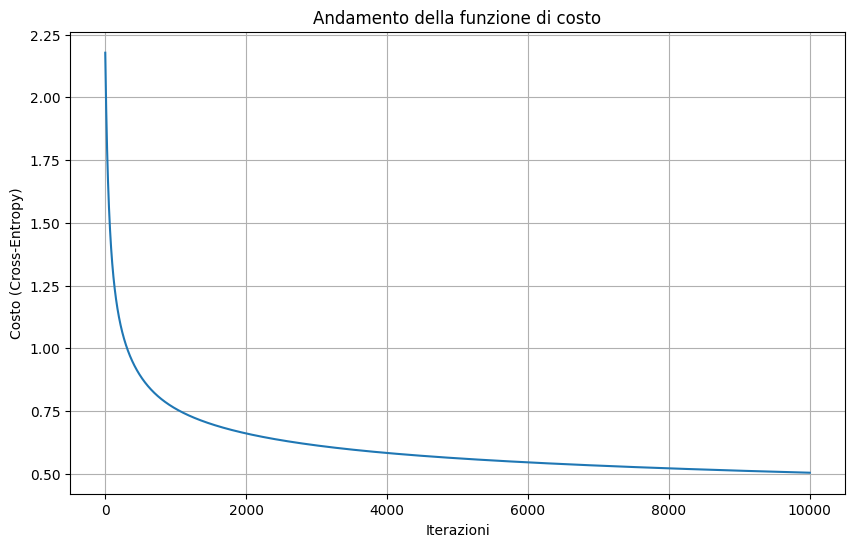

In [120]:
# Istanziazione del modello
logistic_model = MultinomialLogisticRegression(learning_rate=0.01, n_iterations=10000)
# Addestramento del modello
y_train.reset_index(drop=True, inplace=True)
logistic_model.fit(X_train, y_train)
# Visualizzazione dell'andamento della funzione di costo
logistic_model.plot_cost_history()

In [121]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Predizione sui dati di test
y_pred_manual_multi  = logistic_model.predict(X_test)
# Metriche
accuracy_manual_multi = accuracy_score(y_test, y_pred_manual_multi)
precision_manual_multi = precision_score(y_test, y_pred_manual_multi, average='weighted')
recall_manual_multi = recall_score(y_test, y_pred_manual_multi, average='weighted')
f1_manual_multi = f1_score(y_test, y_pred_manual_multi, average='weighted')
# Stampa i risultati
print(f"Accuracy Multinomial manuale: {accuracy_manual_multi:.4f}")
print(f"Precision Multinomial manuale: {precision_manual_multi:.4f}")
print(f"Recall Multinomial manuale: {recall_manual_multi:.4f}")
print(f"F1 Score Multinomial manuale: {f1_manual_multi:.4f}")

Accuracy Multinomial manuale: 0.8056
Precision Multinomial manuale: 0.8457
Recall Multinomial manuale: 0.8056
F1 Score Multinomial manuale: 0.7977


In [122]:
results = pd.DataFrame({
    "Model": [
        "Sklearn Multinomial",
        "Sklearn OVA",
        "Manual Multinomial",
        "Manual OVA"
    ],
    "Accuracy": [
        accuracy_sklearn_multi,
        accuracy_sklearn_ova,
        accuracy_manual_multi,
        accuracy_manual_ova
    ],
    "Precision": [
        precision_sklearn_multi,
        precision_sklearn_ova,
        precision_manual_multi,
        precision_manual_ova
    ],
    "Recall": [
        recall_sklearn_multi,
        recall_sklearn_ova,
        recall_manual_multi,
        recall_manual_ova
    ],
    "F1 Score": [
        f1_sklearn_multi,
        f1_sklearn_ova,
        f1_manual_multi,
        f1_manual_ova
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Sklearn Multinomial,0.850000,0.890673,0.850000,0.832559
1,Sklearn OVA,0.827778,0.876320,0.827778,0.811372
2,Manual Multinomial,0.805556,0.845679,0.805556,0.797736
3,Manual OVA,0.811111,0.850507,0.811111,0.807761


## Confronto finale

- I modelli **sklearn funzionano meglio** rispetto a quelli implementati manualmente.  
  Questo è normale: sklearn usa metodi di ottimizzazione più robusti e già ottimizzati.

- Con sklearn, il modello **multinomiale (softmax)** ottiene i risultati migliori.  
  Ha senso: il modello impara tutte le classi insieme, invece di separarle in problemi binari.

- Nell’implementazione manuale, invece, **OVA va leggermente meglio del multinomiale**.  
  Questo succede perché OVA è più semplice da ottimizzare, mentre il softmax è più delicato e sensibile ai parametri.

### Cosa imparare da questo esercizio

- Il modello “più avanzato” non è sempre quello che funziona meglio in pratica.
- L’**ottimizzazione** e la qualità dell’implementazione fanno una grande differenza.
- OVA è un buon approccio semplice e robusto.
- Il modello multinomiale è più potente, ma richiede un’implementazione più curata.